In [2]:
import pandas as pd
import numpy as np
import pyemu
import yaml
import math
import os
from scipy.special import exp1
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol
from IPython.display import display

In [ ]:
# set up path
target_dir = r"\Python\Personal\proj6\codes\runs\sandbox"
rel_t_d = os.path.relpath(target_dir, os.getcwd()) 
os.chdir(rel_t_d)

In [1]:
##########################
### pit-centric domain ###
##########################

# number of wells
n_wells = 2

# number of realizations
num_reals = 150

# bounds of coordinate system
x_min, x_max = -50, 50
y_min, y_max = -50, 50

# wells cannot be within this many units of the centre (0,0)
no_go_radius = 10.0

# range of pumping rates [m3/day]
q_min, q_max = 6.5, 65

# aquifer properties
T_val = 100.0 # [m2/day]
S_val = 0.001 # [-]
t_eval_val = 365.0 # [day]

######################
### parameter list ###
######################

# define parameter names for the columns
par_names = []
for i in range(1, n_wells + 1):
    par_names.extend([f"well_{i}_x", f"well_{i}_y", f"well_{i}_q"])
par_names.append("xc")

# define bounds dictionary for easy lookup during random draw
bounds = {}
for i in range(1, n_wells + 1):
    bounds[f"well_{i}_x"] = (x_min, x_max)
    bounds[f"well_{i}_y"] = (y_min, y_max)
    bounds[f"well_{i}_q"] = (q_min, q_max)
bounds["xc"] = (x_min, x_max)

###################
### random draw ###
###################

valid_data = []
while len(valid_data) < num_reals:
    # generate random values for all parameters
    row = [np.random.uniform(bounds[p][0], bounds[p][1]) for p in par_names]
    
    # distance check (no-go zone)
    well_coords = []
    for i in range(n_wells):
        # x is index 0,3,6... and y is index 1,4,7...
        well_coords.append([row[i*3], row[i*3+1]])
    
    distances = np.linalg.norm(well_coords, axis=1)
    if np.all(distances > no_go_radius):
        valid_data.append(row)

# create the ensemble dataframe
pop = pd.DataFrame(valid_data, columns=par_names)

# select a random realization to analyze
selected_idx = np.random.choice(pop.index)
selected_real = pop.loc[selected_idx]

# set compliance point y-position
yc = np.random.choice([y_min, y_max])
xc_val = selected_real["xc"]

#################################
### centre of mass of pumping ###
#################################

# pumping-rate-weighted average of well positions
total_q = sum(selected_real[f"well_{i}_q"] for i in range(1, n_wells + 1))

com_x = sum(selected_real[f"well_{i}_x"] * selected_real[f"well_{i}_q"] 
            for i in range(1, n_wells + 1)) / total_q

com_y = sum(selected_real[f"well_{i}_y"] * selected_real[f"well_{i}_q"] 
            for i in range(1, n_wells + 1)) / total_q

# radial distance from CoM to compliance point and pit (targets)
dist_com_to_compliance = np.sqrt((com_x - xc_val)**2 + (com_y - yc)**2)
dist_com_to_pit = np.sqrt(com_x**2 + com_y**2)

# calculate drawdowns using analytical Theis
def get_s(Q, r):
    if r < 1e-3: return 0
    u = (r**2 * S_val) / (4.0 * T_val * t_eval_val)
    return (Q / (4.0 * math.pi * T_val)) * exp1(u)

s_compliance = get_s(total_q, dist_com_to_compliance)
s_pit = get_s(total_q, dist_com_to_pit)

######################
### output summary ###
######################

print(f"Analysis for Realization Index: {selected_idx}")

# well summary table
well_data = []
for i in range(1, n_wells + 1):
    well_data.append({
        "Well": f"{i}",
        "X": selected_real[f"well_{i}_x"],
        "Y": selected_real[f"well_{i}_y"],
        "Q (m3/d)": selected_real[f"well_{i}_q"]
    })

# append CoM as a final row
well_data.append({
    "Well": "CoM",
    "X": com_x,
    "Y": com_y,
    "Q (m3/d)": total_q
})

# drawdown summary table
drawdown_data = [
    {"Target": "Compliance Point", "Radius (m)": dist_com_to_compliance, "Drawdown (m)": s_compliance},
    {"Target": "Pit Centre", "Radius (m)": dist_com_to_pit, "Drawdown (m)": s_pit}
]

# display tables
display(pd.DataFrame(well_data).style.format({"X": "{:.2f}", "Y": "{:.2f}", "Q (m3/d)": "{:.2f}"}).hide(axis='index'))
display(pd.DataFrame(drawdown_data).style.format({"Radius (m)": "{:.2f}", "Drawdown (m)": "{:.2f}"}).hide(axis='index'))

NameError: name 'np' is not defined

In [5]:
######################################
### two well example visualization ###
######################################

fig = go.Figure()

# domain
fig.add_shape(type="rect", x0=x_min, y0=y_min, x1=x_max, y1=y_max, 
              line=dict(color="black"), opacity=0.1)

# no-go zone
fig.add_shape(type="circle", x0=-no_go_radius, y0=-no_go_radius, x1=no_go_radius, y1=no_go_radius, 
              line=dict(color="black", dash="dash"))

# target locations
fig.add_trace(go.Scatter(x=[0], y=[0], mode='markers+text', 
                         text=[f"Open Pit<br>s: {s_pit:.2f}m"],
                         marker=dict(color='black', size=10, symbol='hexagon'), 
                         name="Open Pit", textposition="top center"))

# compliance point
fig.add_trace(go.Scatter(x=[xc_val], y=[yc], mode='markers+text', 
                         text=[f"Compliance Point<br>s: {s_compliance:.2f}m"],
                         marker=dict(color='yellow', size=12, symbol='star', line=dict(width=1, color='black')), 
                         name="Compliance Point", 
                         textposition="top center" if yc == y_min else "bottom center"))

# wells and ensemble
colours = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A']

for i in range(1, n_wells + 1):
    colour = colours[(i-1) % len(colours)]
    
    # Ensemble points from the 'pop' dataframe
    fig.add_trace(go.Scatter(x=pop[f"well_{i}_x"], y=pop[f"well_{i}_y"], 
                             mode='markers', marker=dict(color=colour, opacity=0.1), 
                             name=f"Well {i} Ensemble", showlegend=False))
    
    # selected well position from 'selected_real'
    fig.add_trace(go.Scatter(x=[selected_real[f"well_{i}_x"]], 
                             y=[selected_real[f"well_{i}_y"]],
                             mode='markers+text', text=[f"Well {i}"], 
                             marker=dict(color=colour, size=10, line=dict(width=1, color='white')), 
                             name=f"Well {i} Selected", textposition="top center"))

# centre of mass
fig.add_trace(go.Scatter(x=[com_x], y=[com_y], mode='markers+text', 
                         text=["CoM"], marker=dict(color='black', size=12, symbol='x'), 
                         name="Pumping Centre of Mass", textposition="top center"))

# connectivity from CoM to targets
fig.add_trace(go.Scatter(x=[com_x, xc_val, None, com_x, 0], 
                         y=[com_y, yc, None, com_y, 0], 
                         mode='lines', line=dict(color='grey', width=1, dash='dot'), 
                         showlegend=False))

# pretty up the layout
fig.update_layout(
    xaxis_title="X Coordinate", 
    yaxis_title="Y Coordinate", 
    template="plotly_white", 
    width=750, 
    height=750,
    title=(f"Theis Analysis: Realization Index {selected_idx}<br>"
           f"<sup>Aquifer Parameters: T={T_val} m²/d, S={S_val}</sup>"),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02)
)

fig.show()


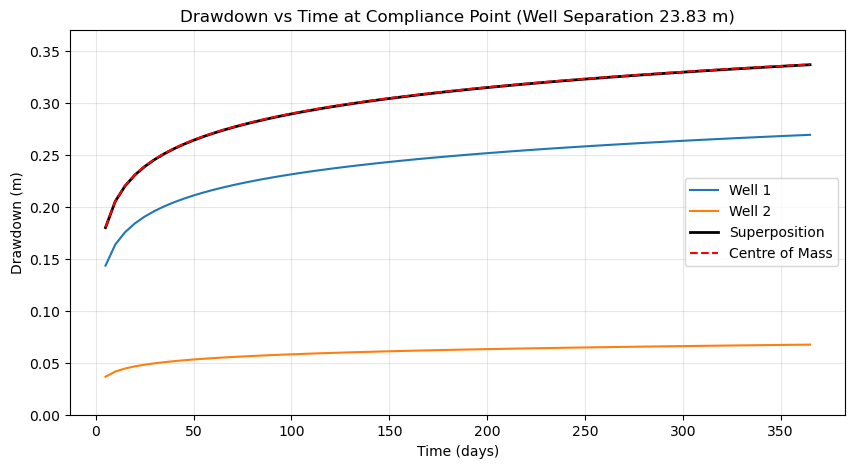

In [8]:
#################################################
### drawdown vs time plot at compliance point ###
#################################################

# time steps for drawdown evaluation
t_series = np.arange(5, t_eval_val + 5, 5)

# coordinates for wells and compliance point
# wells
w1_coords = (selected_real["well_1_x"], selected_real["well_1_y"])
w2_coords = (selected_real["well_2_x"], selected_real["well_2_y"])
# compliance point
cp_coords = (xc_val, yc) 

# calculate radial distances to compliance point
def dist(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

r1_cp = dist(w1_coords, cp_coords)
r2_cp = dist(w2_coords, cp_coords)
r_com_cp = dist((com_x, com_y), cp_coords)

# calculate trace drawdowns at compliance point using Theis solution
def theis_s(Q, r, t):
    u = (r**2 * S_val) / (4.0 * T_val * t)
    return (Q / (4.0 * math.pi * T_val)) * exp1(u)

s1_cp = theis_s(selected_real["well_1_q"], r1_cp, t_series)
s2_cp = theis_s(selected_real["well_2_q"], r2_cp, t_series)
s_total_cp = s1_cp + s2_cp
s_com_cp = theis_s(total_q, r_com_cp, t_series)

# plot
plt.figure(figsize=(10, 5))
plt.plot(t_series, s1_cp, label='Well 1', linestyle='-')
plt.plot(t_series, s2_cp, label='Well 2', linestyle='-')
plt.plot(t_series, s_total_cp, label='Superposition', color='black', lw=2)
plt.plot(t_series, s_com_cp, label='Centre of Mass', color='red', linestyle='--')

plt.title(f'Drawdown vs Time at Compliance Point (Well Separation {dist(w1_coords, w2_coords):.2f} m)')
plt.xlabel('Time (days)')
plt.ylabel('Drawdown (m)')
plt.ylim(0, max(s_total_cp)*1.1)
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()


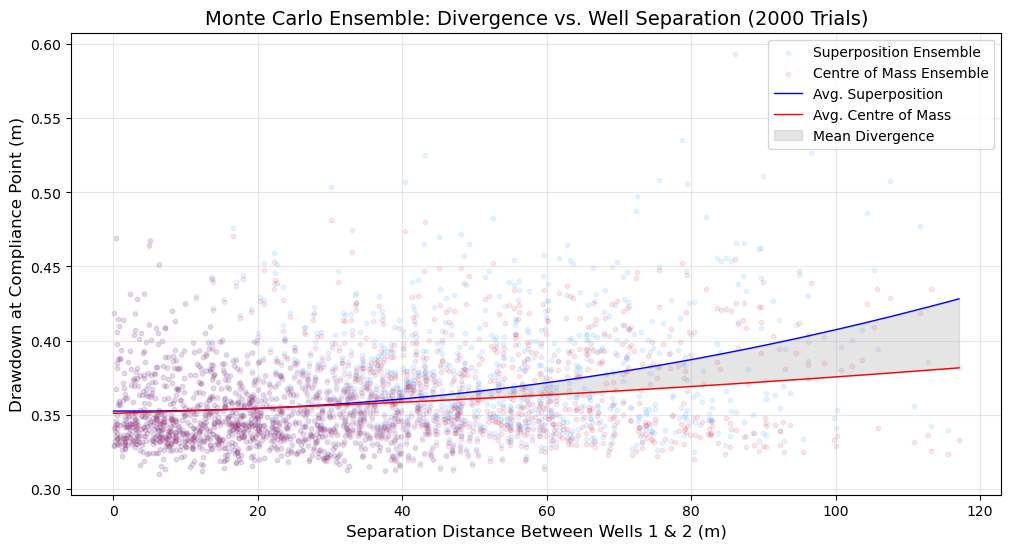

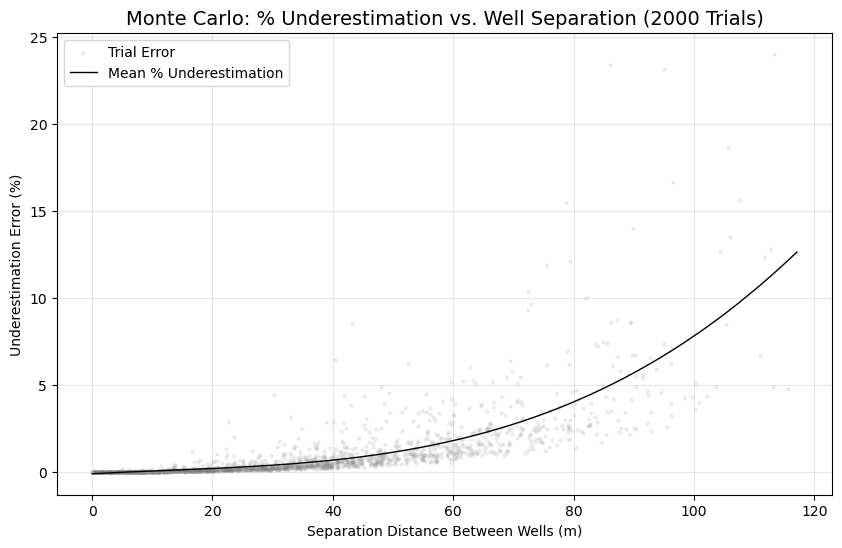

In [9]:
### distance is squared (r**2) inside the Theis function
### therefore the drawdown doesn't decrease linearly
### thus the average of two drawdowns is never the same as the drawdown at the average distance (Jensen's inequality)

########################################################
### monte carlo proof - drawdown at compliance point ### 
########################################################

# monte carlo parameters
num_trials = 2000
T, S, t = T_val, S_val, t_eval_val
q1 = selected_real["well_1_q"]
q2 = selected_real["well_2_q"]
q_total = q1 + q2

# initialize dict for results
mc_res = []

def get_valid_well():
    """Generates a well position that honours the no go radius from the pit centre"""
    while True:
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        if math.sqrt(x**2 + y**2) >= no_go_radius:
            return np.array([x, y])

# run monte carlo trials
for _ in range(num_trials):
    # place two valid wells
    w1 = get_valid_well()
    w2 = get_valid_well()

    # calculate radial distances to compliance point
    r1_cp = np.linalg.norm(w1 - cp_coords)
    r2_cp = np.linalg.norm(w2 - cp_coords)
    r_com_cp = (r1_cp*q1 + r2_cp*q2) / q_total
    current_separation = abs(r1_cp - r2_cp)
    
    # calculate drawdown assuming superposition
    u1 = (r1_cp**2 * S) / (4.0 * T * t)
    u2 = (r2_cp**2 * S) / (4.0 * T * t)
    s_sup = (q1/(4*np.pi*T))*exp1(u1) + (q2/(4*np.pi*T))*exp1(u2)
    
    # calculate drawdown assuming CoM approximation
    r_com = (r1_cp*q1 + r2_cp*q2) / q_total # r_com = weighted average distance
    u_com = (r_com**2 * S) / (4.0 * T * t)
    s_com = (q_total/(4*np.pi*T))*exp1(u_com)
    
    mc_res.append([current_separation, r1_cp, r2_cp, r_com_cp, s_sup, s_com])

# convert to numpy array for easy indexing
mc_res_arr = np.array(mc_res)
sep_dist = mc_res_arr[:, 0]
sup_s = mc_res_arr[:, 4]
com_s = mc_res_arr[:, 5]

# plot
plt.figure(figsize=(12, 6))
plt.scatter(sep_dist, sup_s, color='dodgerblue', alpha=0.1, s=10, label='Superposition Ensemble')
plt.scatter(sep_dist, com_s, color='crimson', alpha=0.1, s=10, label='Centre of Mass Ensemble')

# polyfit shows the mean behavior of the ensembles
z_true = np.polyfit(sep_dist, sup_s, 2)
p_true = np.poly1d(z_true)
z_com = np.polyfit(sep_dist, com_s, 2)
p_com = np.poly1d(z_com)

sorted_sep = np.sort(sep_dist)
plt.plot(sorted_sep, p_true(sorted_sep), 'b-', lw=1, label='Avg. Superposition')
plt.plot(sorted_sep, p_com(sorted_sep), 'r-', lw=1, label='Avg. Centre of Mass')

# format
plt.fill_between(sorted_sep, p_true(sorted_sep), p_com(sorted_sep), color='grey', alpha=0.2, label='Mean Divergence')
plt.title(f'Monte Carlo Ensemble: Divergence vs. Well Separation ({num_trials} Trials)', fontsize=14)
plt.xlabel('Separation Distance Between Wells 1 & 2 (m)', fontsize=12)
plt.ylabel('Drawdown at Compliance Point (m)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

######################################
### monte carlo proof - % at error ### 
######################################

# 1. calculate % error for each trial in ensemble
p_errors = (sup_s - com_s) / sup_s * 100

# plot
plt.figure(figsize=(10, 6))
plt.scatter(sep_dist, p_errors, color='grey', alpha=0.1, s=5, label='Trial Error')

# polyfit shows the mean behavior of the ensembles
idx = np.argsort(sep_dist)
z = np.polyfit(sep_dist, p_errors, 3)
p_trend = np.poly1d(z)
plt.plot(sep_dist[idx], p_trend(sep_dist[idx]), 'k-', lw=1, label='Mean % Underestimation')

# annotate
# plt.axhline(5, color='red', linestyle='--', label='5% Error Threshold') # define threshold for "safe zone"
plt.title('Monte Carlo: % Underestimation vs. Well Separation' f' ({num_trials} Trials)', fontsize=14)
plt.xlabel('Separation Distance Between Wells (m)')
plt.ylabel('Underestimation Error (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_56356\3859852579.py:29: DeprecationWarning:

`salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`



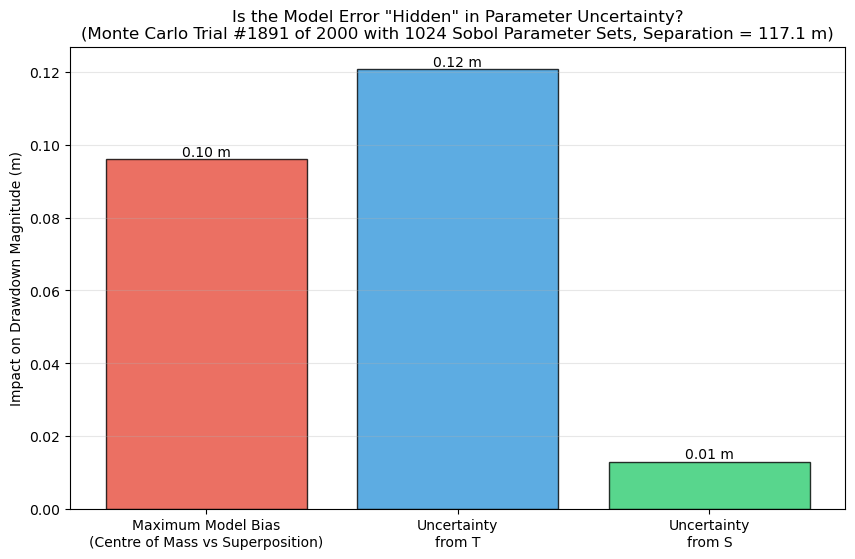

In [10]:
####################################################
### sobol analysis - maximum seperation distance ###
####################################################

# the total contribution to the output variance from each parameter (including its interactions with others)
# if the uncertainty from T is much more than the "Model Bias", 
# the error from using the CoM approximation is "hidden" or negligible 
# compared to the natural uncertainty of not knowing the exact aquifer properties

sample_size = 1024 # common choice for Sobol analysis 
# N*(2D+2) = 1024 => N = 256

# select a random index with the maximum separation distance from the Monte Carlo trials
random_idx = np.argmax(mc_res_arr[:, 0]) 

# extract the distances from that specific trial
selected_sep = mc_res_arr[random_idx, 0]
selected_r1 = mc_res_arr[random_idx, 1]
selected_r2 = mc_res_arr[random_idx, 2]
selected_r_com = mc_res_arr[random_idx, 3]

# define the problem for Sobol analysis
problem = {
    'num_vars': 2,
    'names': ['T', 'S'],
    'bounds': [[T_val*0.5, T_val*1.5], [S_val*0.5, S_val*1.5]]
}
# generate number of parameter sets based on these specific bounds
param_values = saltelli.sample(problem, sample_size)

# evaluate the model (drawdown at compliance point) for each parameter set in sample
Y_sup = []
Y_com = []

for p in param_values:
    Ti, Si = p
    
    # drawdown assuming superposition
    u1, u2 = (selected_r1**2 * Si)/(4*Ti*t), (selected_r2**2 * Si)/(4*Ti*t)
    s_t = (q1/(4*np.pi*Ti))*exp1(u1) + (q2/(4*np.pi*Ti))*exp1(u2)
    Y_sup.append(s_t)
    
    # drawdown assuming CoM approximation
    u_c = (selected_r_com**2 * Si)/(4*Ti*t)
    s_c = (q_total/(4*np.pi*Ti))*exp1(u_c)
    Y_com.append(s_c)

Y_sup = np.array(Y_sup)
Y_com = np.array(Y_com)

# analyze Sobol on the superposition drawdown results (Y_sup)
# returns the total variance and the total sensitivity indices for T and S
Si_res = sobol.analyze(problem, Y_sup)
total_var = np.var(Y_sup)

# calculate the model bias and parameter uncertainty in terms of their impact on drawdown magnitude
# estimate the parameter uncertainty: square root of the partial variance (ST * total_var)
max_bias = np.max(np.abs(Y_sup - Y_com)) # maximum physical difference between the two models across the parameter space
uncert_T = np.sqrt(Si_res['ST'][0] * total_var) # uncertainty in drawdown caused by T
uncert_S = np.sqrt(Si_res['ST'][1] * total_var) # uncertainty in drawdown caused by S

# plot

impacts = [max_bias, uncert_T, uncert_S]
labels = ['Maximum Model Bias\n(Centre of Mass vs Superposition)', 'Uncertainty\nfrom T', 'Uncertainty\nfrom S']

plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = plt.bar(labels, impacts, color=colors, alpha=0.8, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f} m', 
             ha='center', va='bottom')

plt.ylabel('Impact on Drawdown Magnitude (m)')

# select a random index from the Monte Carlo trials
random_idx = np.random.randint(0, num_trials)

plt.title(f'Is the Model Error "Hidden" in Parameter Uncertainty?\n(Monte Carlo Trial #{random_idx} of {num_trials} with {sample_size} Sobol Parameter Sets, Separation = {selected_sep:.1f} m)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
# parameters for the loop
n_iterations = 1000
bias_exceeds_T = 0
bias_exceeds_S = 0

# define the problem for Sobol analysis
problem = {
    'num_vars': 2,
    'names': ['T', 'S'],
    'bounds': [[T_val*0.5, T_val*1.5], [S_val*0.5, S_val*1.5]]
}

# pre-generate parameter sets
param_values = saltelli.sample(problem, 1024)

for i in range(n_iterations):
    # pick a random spatial configuration from existing Monte Carlo results
    idx = np.random.randint(0, len(mc_res))
    r1, r2, r_com = mc_res[idx][1], mc_res[idx][2], mc_res[idx][3]
    
    Y_sup = []
    Y_com = []
    
    # evaluate models across the Sobol parameter sets
    for p in param_values:
        Ti, Si = p

        # calculate drawdown assuming superposition
        u1, u2 = (r1**2 * Si)/(4*Ti*t), (r2**2 * Si)/(4*Ti*t)
        s_t = (q1/(4*np.pi*Ti))*exp1(u1) + (q2/(4*np.pi*Ti))*exp1(u2)
        Y_sup.append(s_t)
        
        # calculate drawdown assuming CoM approximation
        u_c = (r_com**2 * Si)/(4*Ti*t)
        s_c = (q_total/(4*np.pi*Ti))*exp1(u_c)
        Y_com.append(s_c)

    Y_sup = np.array(Y_sup)
    Y_com = np.array(Y_com)
    
    # analyze sensitivity on the superposition drawdown results (Y_sup)
    Si_results = sobol.analyze(problem, Y_sup, print_to_console=False)
    total_var = np.var(Y_sup)
    
    # calculate the model bias and parameter uncertainty in terms of their impact on drawdown magnitude
    # estimate the parameter uncertainty: square root of the partial variance (ST * total_var)
    max_bias = np.max(np.abs(Y_sup - Y_com)) # maximum physical difference between the two models across the parameter space
    uncert_T = np.sqrt(Si_res['ST'][0] * total_var) # uncertainty in drawdown caused by T
    uncert_S = np.sqrt(Si_res['ST'][1] * total_var) # uncertainty in drawdown caused by S
    
    if max_bias > uncert_T:
        bias_exceeds_T += 1
    if max_bias > uncert_S:
        bias_exceeds_S += 1

# report
print(f"Out of {n_iterations} Monte Carlo trials and {sample_size} Sobol parameter sets:")
print(f"- Maximum Bias Exceeded T-uncertainty: {bias_exceeds_T} times ({(bias_exceeds_T/n_iterations)*100:.1f}%)")
print(f"- Maximum Bias Exceeded S-uncertainty: {bias_exceeds_S} times ({(bias_exceeds_S/n_iterations)*100:.1f}%)")

C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_56356\2990774258.py:14: DeprecationWarning:

`salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`



Out of 1000 Monte Carlo trials and 1024 Sobol parameter sets:
- Maximum Bias Exceeded T-uncertainty: 0 times (0.0%)
- Maximum Bias Exceeded S-uncertainty: 143 times (14.3%)
